In [0]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Amazon Reviews EDA") \
    .getOrCreate()

In [0]:
path = "/Volumes/workspace/default/appliances_review/appliances_review.jsonl"

df = spark.read \
    .option("multiLine", "false") \
    .json(path)

In [0]:
reviews_path = "/Volumes/workspace/default/appliances_review/appliances_review.jsonl"
reviews_df = spark.read.option("multiLine", "false").json(reviews_path)


In [0]:
reviews_df.printSchema()


root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



In [0]:
reviews_df.show()

+----------+------------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+
|      asin|helpful_vote|parent_asin|rating|                text|    timestamp|               title|             user_id|verified_purchase|
+----------+------------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+
|B01N0TQ0OH|           0| B01N0TQ0OH|   5.0|work great. use a...|1519317108692|          Work great|AGKHLEW2SOWHNMFQI...|             true|
|B07DD2DMXB|           0| B07DD37QPZ|   5.0|Little on the thi...|1664746863446|   excellent product|AHWWLSPCJMALVHDDV...|             true|
|B082W3Z9YK|           0| B082W3Z9YK|   5.0|Quick delivery, f...|1607225435363|     Happy customer!|AHZIJGKEWRTAEOZ67...|             true|
|B078W2BJY8|           0| B078W2BJY8|   5.0|I wasn't sure whe...|1534104184306|       Amazing value|AFGUPTDFAWOHHL4LZ...|             true|
|B08C9LPCQV|        

**STEP 1 — How big is the data**

In [0]:
reviews_df.count()

1978085

**STEP 2 — Missing values**

In [0]:
from pyspark.sql.functions import col, sum

reviews_df.select([
    sum(col(c).isNull().cast("int")).alias(f"{c}_missing")
    for c in reviews_df.columns
]).show(truncate=False)


+------------+--------------------+-------------------+--------------+------------+-----------------+-------------+---------------+-------------------------+
|asin_missing|helpful_vote_missing|parent_asin_missing|rating_missing|text_missing|timestamp_missing|title_missing|user_id_missing|verified_purchase_missing|
+------------+--------------------+-------------------+--------------+------------+-----------------+-------------+---------------+-------------------------+
|0           |0                   |0                  |0             |0           |0                |0            |0              |0                        |
+------------+--------------------+-------------------+--------------+------------+-----------------+-------------+---------------+-------------------------+



In [0]:
## STEP 3 — Rating distribution
reviews_df.groupBy("rating") \
    .count() \
    .orderBy("rating") \
    .show()


+------+-------+
|rating|  count|
+------+-------+
|   1.0| 236362|
|   2.0|  73583|
|   3.0|  94700|
|   4.0| 185317|
|   5.0|1388123|
+------+-------+



In [0]:
## STEP 4 — Invalid ratings
reviews_df.filter(
    (col("rating") < 1) | (col("rating") > 5)
).count()


0

In [0]:
## Step 5 Review text Length

from pyspark.sql.functions import length

reviews_df = reviews_df.withColumn(
    "review_length", length("text")
)

reviews_df.select("review_length").describe().show()


+-------+------------------+
|summary|     review_length|
+-------+------------------+
|  count|           1978085|
|   mean|159.81542956950787|
| stddev| 258.8390099389501|
|    min|                 0|
|    max|             30004|
+-------+------------------+



In [0]:
## Step 6 Helpful Votes
reviews_df.select("helpful_vote").describe().show()


+-------+------------------+
|summary|      helpful_vote|
+-------+------------------+
|  count|           1978085|
|   mean|0.8342897297133338|
| stddev| 11.87285685964213|
|    min|                 0|
|    max|              5704|
+-------+------------------+



In [0]:
reviews_df.filter(col("helpful_vote") > 0).count()


361856

In [0]:
## STEP 7 — Verified vs Non-verified
reviews_df.groupBy("verified_purchase") \
    .count() \
    .show()

+-----------------+-------+
|verified_purchase|  count|
+-----------------+-------+
|             true|1908028|
|            false|  70057|
+-----------------+-------+



In [0]:
##STEP 8 — Time range of reviews
from pyspark.sql.functions import from_unixtime, min, max

reviews_df.withColumn(
    "review_time",
    from_unixtime(col("timestamp"))
).select(
    min("review_time").alias("min_date"),
    max("review_time").alias("max_date")
).show()

+--------------------+--------------------+
|            min_date|            max_date|
+--------------------+--------------------+
|+46969-08-12 13:4...|+55667-09-18 00:0...|
+--------------------+--------------------+



In [0]:
## correlation between helpfulvotes and rating
reviews_df.stat.corr("helpful_vote", "rating")


-0.02636715950964791

In [0]:
total_count = reviews_df.count()
distinct_count = reviews_df.dropDuplicates().count()

print("Total:", total_count)
print("Duplicates:", total_count - distinct_count)


Total: 1978085
Duplicates: 21078


In [0]:
from pyspark.sql.functions import count

reviews_df.groupBy("user_id", "asin") \
    .count() \
    .filter("count > 1") \
    .orderBy("count", ascending=False) \
    .show()


+--------------------+----------+-----+
|             user_id|      asin|count|
+--------------------+----------+-----+
|AGBGK5JONOQ7OJEJJ...|B07P3H652K|   11|
|AFB32N5EIVER7YQSE...|B084D61MML|   10|
|AGPD4DZYLFIVX36IS...|B076P93X7V|    9|
|AEIJV4O23Y5XAGGCO...|B08KFL6B5P|    9|
|AENHAAJGKM3ZZZIUS...|B07TGD2245|    9|
|AF6PA4YKGG4WX7H6Y...|B077XWSM7L|    8|
|AHKV2DNQ4WY5VERJ5...|B00DUGIO36|    8|
|AF2GA6QK5A2F6MJUT...|B00HNEJHT6|    8|
|AGOELI63KML3B6DUY...|B08QHJYPFW|    8|
|AGVAA24XJSIPO6ZLH...|B0052EDYFC|    8|
|AE2GBJRPP2FDUICP6...|B008YDSRZK|    8|
|AHKV2DNQ4WY5VERJ5...|B004H3XRDI|    8|
|AE3FCVJLMEYKTYBAU...|B07HFPS88T|    8|
|AHEVWFV3FKMI5FNS3...|B01N63XMK4|    8|
|AGKTDJRORZ2FT3OJ5...|B075M3WDST|    8|
|AHH6TK7DOWMNTZSKG...|B078TGXGPX|    8|
|AHZVLQRMSGA3A4MR3...|B078TGXGPX|    8|
|AHZVLQRMSGA3A4MR3...|B0789FR9JK|    8|
|AGQJPE2KK6FMTZWQL...|B09D2V5C8N|    7|
|AFHEFE3DSHY7BJ5WL...|B082NR9R33|    7|
+--------------------+----------+-----+
only showing top 20 rows


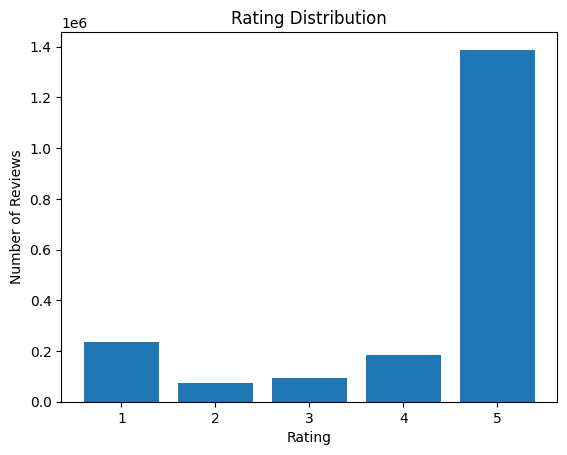

In [0]:
# Rating Distribution (Bar Chart)
# Shows overall customer satisfaction.

rating_df = (
    reviews_df.groupBy("rating")
    .count()
    .orderBy("rating")
    .toPandas()
)

import matplotlib.pyplot as plt

plt.bar(rating_df["rating"], rating_df["count"])
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Rating Distribution")
plt.show()

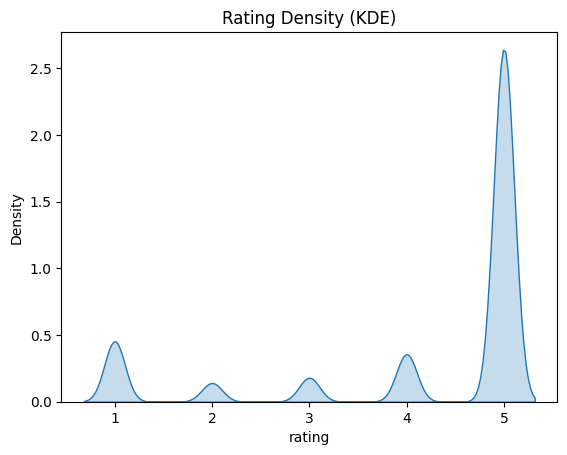

In [0]:
# Rating Density (KDE Plot)
# Smooth view of rating concentration.

rating_sample = reviews_df.select("rating").sample(0.2).toPandas()

import seaborn as sns

sns.kdeplot(rating_sample["rating"], fill=True)
plt.title("Rating Density (KDE)")
plt.show()

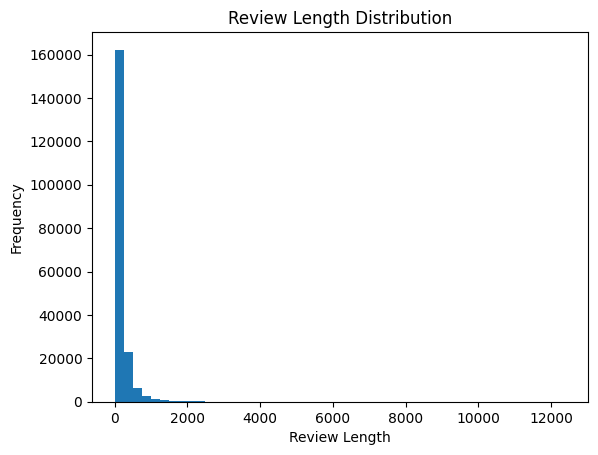

In [0]:
# Review Length Distribution (Histogram)
# Long reviews = complaints / return reasons.

length_df = reviews_df.select("review_length").sample(0.1).toPandas()

plt.hist(length_df["review_length"], bins=50)
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Review Length Distribution")
plt.show()

# Heavy tail → angry customers write more

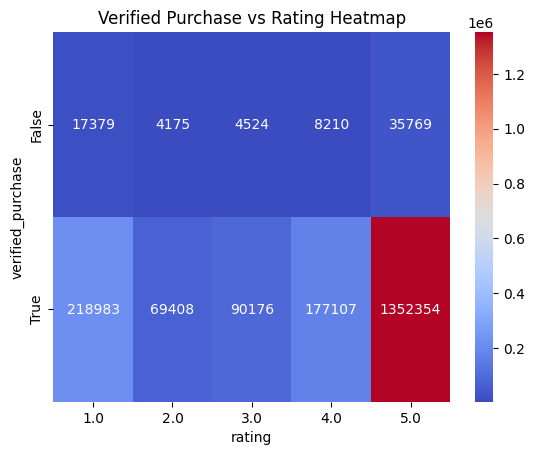

In [0]:
# Heatmap: Rating vs Verified Purchase
# Trust & fake-review detection.

heat_df = (
    reviews_df.groupBy("verified_purchase", "rating")
    .count()
    .toPandas()
)

pivot = heat_df.pivot(
    index="verified_purchase",
    columns="rating",
    values="count"
)

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Verified Purchase vs Rating Heatmap")
plt.show()

# Verified Purchase Trust Score
# Customer Trust Index

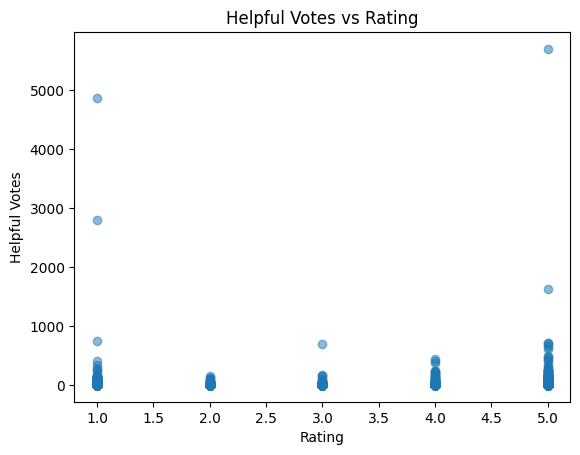

In [0]:
# Helpful Votes vs Rating (Scatter)
# Which reviews influence customers most.

helpful_df = (
    reviews_df
    .filter("helpful_vote > 0")
    .sample(0.1)
    .select("rating", "helpful_vote")
    .toPandas()
)

plt.scatter(helpful_df["rating"], helpful_df["helpful_vote"], alpha=0.5)
plt.xlabel("Rating")
plt.ylabel("Helpful Votes")
plt.title("Helpful Votes vs Rating")
plt.show()

# Low rating + high helpful = serious product issue

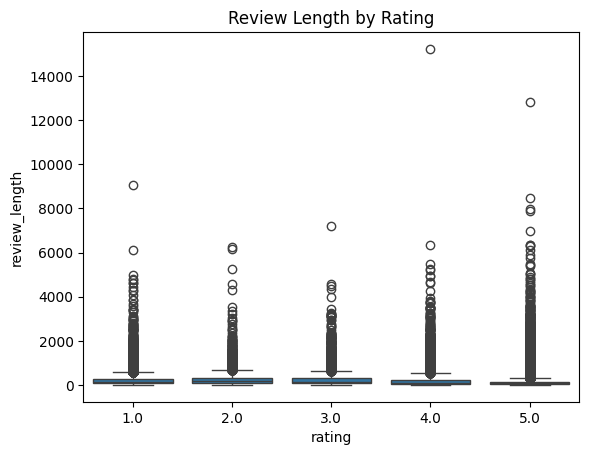

In [0]:
# Boxplot: Review Length by Rating
# Identifies complaint-heavy ratings.

box_df = (
    reviews_df
    .sample(0.1)
    .select("rating", "review_length")
    .toPandas()
)

sns.boxplot(x="rating", y="review_length", data=box_df)
plt.title("Review Length by Rating")
plt.show()

# Return explanation extraction

###{{{Take review Length 3500 for ML Model}}}

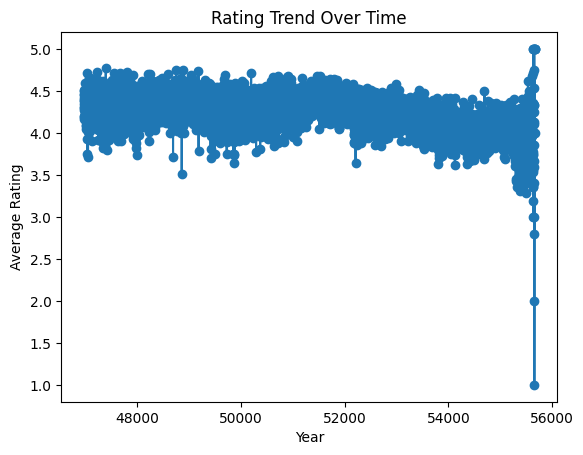

In [0]:
from pyspark.sql.functions import year, from_unixtime

# Add review_year column
reviews_df = reviews_df.withColumn("review_year", year(from_unixtime(col("timestamp"))))

# Average Rating Over Time
rating_time_df = (
    reviews_df.groupBy("review_year")
    .avg("rating")
    .orderBy("review_year")
    .toPandas()
)

import matplotlib.pyplot as plt

plt.plot(
    rating_time_df["review_year"],
    rating_time_df["avg(rating)"],
    marker="o"
)
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.title("Rating Trend Over Time")
plt.show()

# Quality degradation detection

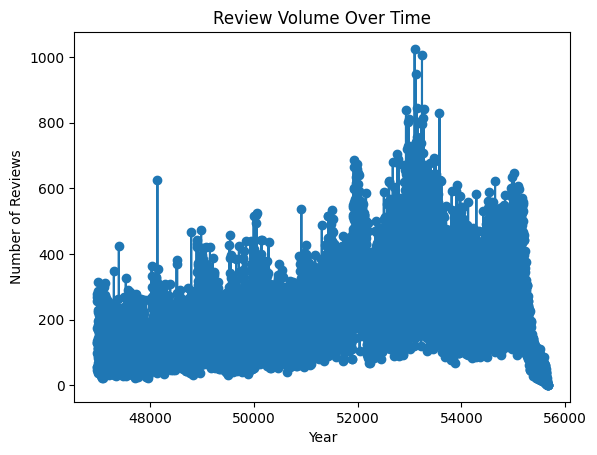

In [0]:
time_df = (
    reviews_df.groupBy("review_year")
    .count()
    .orderBy("review_year")
    .toPandas()
)

plt.plot(time_df["review_year"], time_df["count"], marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Review Volume Over Time")
plt.show()
